# Fourier GID hierarchy on the circle

This notebook demonstrates the geometric information decomposition (GID) on the circle.  On `S^1`, the hierarchy uses Fourier features: cosine and sine terms up to frequency `L`.

The goal is to show the basic interpretation:

- a unimodal von Mises distribution activates the first gap;
- an antipodal mixture activates the second gap;
- a three-mode symmetric mixture activates the third gap.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

## Simulate three circular distributions

We use equal weights in this first display.  The object passed to the computations is still a weighted empirical probability measure; equal weights simply recover the usual empirical distribution.

In [2]:

rng = np.random.default_rng(20260703)
n = 500
weights = np.full(n, 1/n)

scenarios = {
    "Unimodal von Mises": src.sample_vonmises_s1(n, mu=0.0, kappa=5.5, rng=rng),
    "Antipodal mixture": src.sample_mixture_vonmises_s1(
        n, mus=[0.0, np.pi], kappas=7.0, probs=[0.5, 0.5], rng=rng
    ),
    "Trimodal mixture": src.sample_mixture_vonmises_s1(
        n, mus=[0.0, 2*np.pi/3, 4*np.pi/3], kappas=5.5, probs=None, rng=rng
    ),
}

rows = []
fits_by_name = {}
for name, theta in scenarios.items():
    out = src.fit_fourier_hierarchy_s1(theta, weights, max_L=4, grid_size=2048)
    fits_by_name[name] = out
    rows.append({
        "Scenario": name,
        "ESS": src.effective_sample_size(weights),
        "I1": out["I"][0],
        "I2": out["I"][1],
        "I3": out["I"][2],
        "I4": out["I"][3],
        "D4": out["D"][-1],
        "Dominant gap": f"I{np.argmax(out['I']) + 1}",
    })

table = pd.DataFrame(rows)
table.round({"ESS": 1, "I1": 3, "I2": 3, "I3": 3, "I4": 3, "D4": 3})


,Scenario,ESS,I1,I2,I3,I4,D4,Dominant gap
0,Unimodal von Mises,500.0,1.186,0.002,0.004,0.002,1.194,I1
1,Antipodal mixture,500.0,0.001,0.600,0.000,0.006,0.607,I2
2,Trimodal mixture,500.0,0.002,0.004,0.228,0.001,0.236,I3


The dominant gap changes with the geometry: first order for a single direction, second order for antipodal structure, and third order for the threefold pattern.

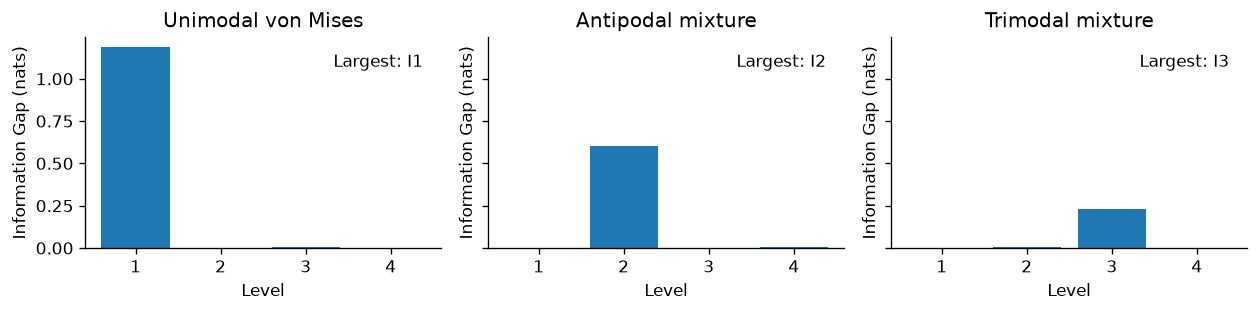

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.7), sharey=True)
levels = np.arange(1, 5)
for ax, row in zip(axes, rows):
    vals = [row[f"I{k}"] for k in levels]
    ax.bar(levels, vals)
    ax.set_title(row["Scenario"])
    ax.set_xlabel("Level")
    ax.set_xticks(levels)
    ax.set_ylabel("Information Gap (nats)")
    ax.text(0.95, 0.92, f"Largest: {row['Dominant gap']}", transform=ax.transAxes, ha="right", va="top")
fig.tight_layout()
plt.show()


## How the trimodal hierarchy fills in modes

The next plot shows the empirical kernel density and the fitted maximum-entropy projections for the trimodal example.  The first two projections miss the threefold symmetry, while the third projection captures it.

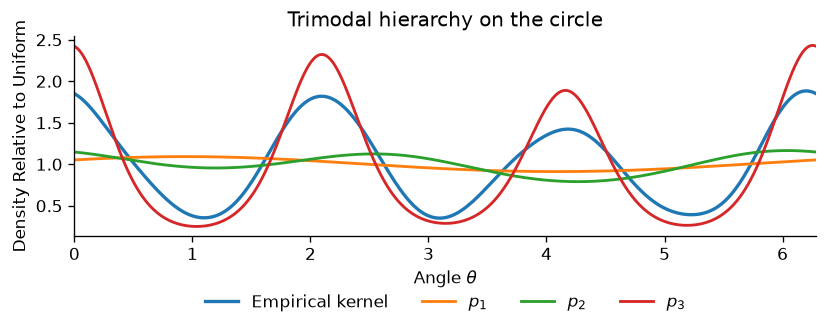

In [4]:

theta = scenarios["Trimodal mixture"]
out = fits_by_name["Trimodal mixture"]
grid = out["grid"]
emp = src.von_mises_kernel_density_s1(theta, weights, grid, kappa=14.0)

fig, ax = plt.subplots(figsize=(7.0, 3.0))
ax.plot(grid, emp, label="Empirical kernel", linewidth=2.0)
for L in [1, 2, 3]:
    fit = out["fits"][L-1]
    phi_grid = src.features_s1_fourier(grid, L)
    dens = np.exp(phi_grid @ fit.lam - fit.psi)
    ax.plot(grid, dens, label=fr"$p_{L}$", linewidth=1.7)
ax.set_xlabel(r"Angle $\theta$")
ax.set_ylabel("Density Relative to Uniform")
ax.set_title("Trimodal hierarchy on the circle")
ax.set_xlim(0, 2*np.pi)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.22), frameon=False)
fig.tight_layout()
plt.show()


## Nonuniform weights

The same code accepts arbitrary nonnegative weights.  Here we assign independent Pareto weights to the trimodal sample.  The effective sample size decreases, and small leakage appears in lower levels, but the third gap remains dominant.

In [5]:

raw = 1 + rng.pareto(a=2.0, size=n)
pareto_w = src.normalize_weights(raw)
out_pareto = src.fit_fourier_hierarchy_s1(theta, pareto_w, max_L=4, grid_size=2048)

pd.DataFrame([{
    "Weights": "Pareto",
    "ESS": src.effective_sample_size(pareto_w),
    "I1": out_pareto["I"][0],
    "I2": out_pareto["I"][1],
    "I3": out_pareto["I"][2],
    "I4": out_pareto["I"][3],
    "D4": out_pareto["D"][-1],
    "Dominant gap": f"I{np.argmax(out_pareto['I']) + 1}",
}]).round(3)


,Weights,ESS,I1,I2,I3,I4,D4,Dominant gap
0,Pareto,226.705,0.001,0.001,0.259,0.0,0.261,I3
